# Experiment Visualization from Training Logs

**This notebook is used for visualizing the experiments of UltraGCN, we have colllected the training logs (in .txt format) in all of the ipynbs inside the experiment folder with the same format structure and plotting necessary metrics into graph for better visualization**

**Read Log**

In [51]:
import re
import matplotlib.pyplot as plt
import numpy as np
import os

**We write a plotting function to visualize the 2 important metrics: Recall and NDCG as well as visualizing the system metrics performance base on the Log Pattern**

**Example Log Sample**

**EPOCH[0/2000] loss:49.226 | F1:0.0028 | P:0.0015 | R:0.0295 | NDCG:0.0124 | T:21.94s | RAM:2519.7MB | CPU:15.3% | VRAM:23.7MB**

**We utilize the re library to get extract the recall, ndcg, ram and vram metrics**


In [52]:
def plot_metrics_from_log(log_path: str) -> str:
    recall_vals = []
    ndcg_vals = []
    ram_vals = []
    vram_vals = []
    title_prefix = os.path.splitext(os.path.basename(log_path))
    title_prefix = title_prefix[0] + ' run'
    pattern = re.compile(
        r"EPOCH\[(\d+)/\d+\].*?R:(\d+\.\d+).*?NDCG:(\d+\.\d+).*?RAM:(\d+\.\d+)MB.*?VRAM:(\d+\.\d+)MB"
    )
    epochs = []


    with open(log_path, 'r', encoding = 'utf-8') as fin:
        for line in fin:
            match = pattern.search(line)
            if match:
                epoch = int(match.group(1))
                recall = float(match.group(2))
                ndcg = float(match.group(3))
                ram = float(match.group(4))
                vram = float(match.group(5))

                epochs.append(epoch)
                recall_vals.append(recall)
                ndcg_vals.append(ndcg)
                ram_vals.append(ram)
                vram_vals.append(vram)
    avg_ram = np.mean(np.array(ram_vals))
    avg_vram = np.mean(np.array(vram_vals))
    print(f'Average System RAM: {avg_ram:.2f}', )
    print(f'Average System VRAM: {avg_vram:.2f}', )

    fig, axs = plt.subplots(1, 4, figsize=(16, 4))
    # Recall
    axs[0].plot(epochs, recall_vals, color="orange")
    axs[0].set_title(f"{title_prefix} - Recall")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Recall")

    # NDCG
    axs[1].plot(epochs, ndcg_vals, color="green")
    axs[1].set_title(f"{title_prefix} - NDCG")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("NDCG")

    # RAM
    axs[2].plot(epochs, ram_vals, color="blue")
    axs[2].set_title(f"{title_prefix} - RAM Usage")
    axs[2].set_xlabel("Epoch")
    axs[2].set_ylabel("RAM (MB)")

    # VRAM
    axs[3].plot(epochs, vram_vals, color="purple")
    axs[3].set_title(f"{title_prefix} - VRAM Usage")
    axs[3].set_xlabel("Epoch")
    axs[3].set_ylabel("VRAM (MB)")

    plt.tight_layout()
    plt.show()

**Yelp2018**

Average System RAM: 6906.99
Average System VRAM: 83.19


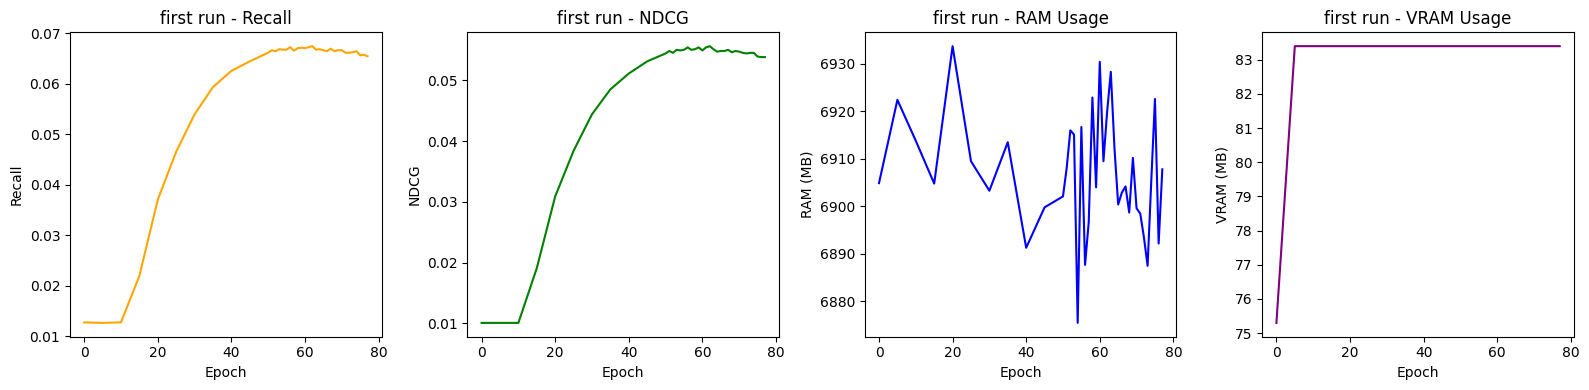

In [53]:
plot_metrics_from_log("yelp2018/first.txt")

Average System RAM: 7367.44
Average System VRAM: 83.16


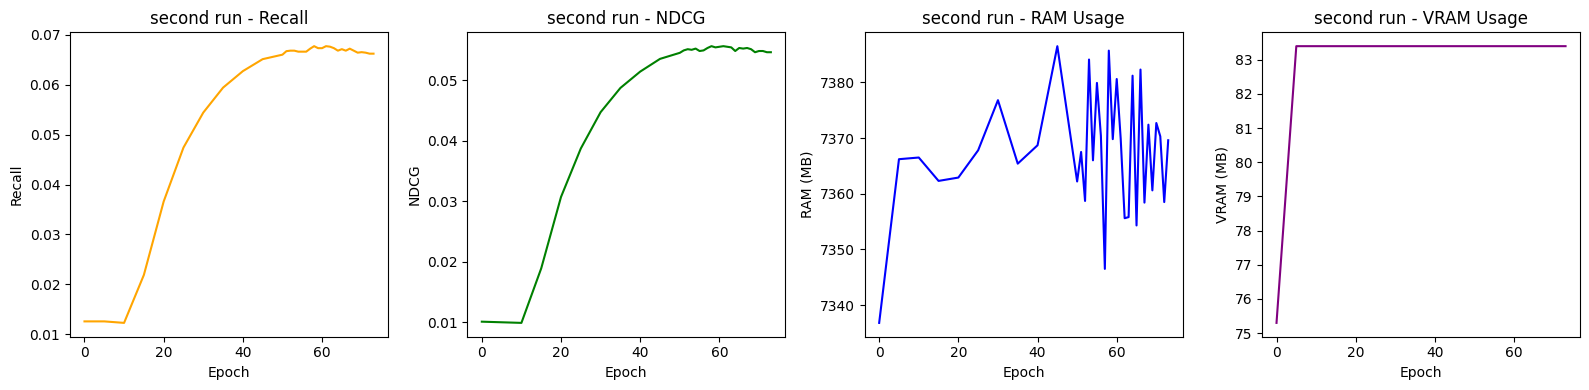

In [54]:
plot_metrics_from_log("yelp2018/second.txt")

Average System RAM: 7402.76
Average System VRAM: 83.18


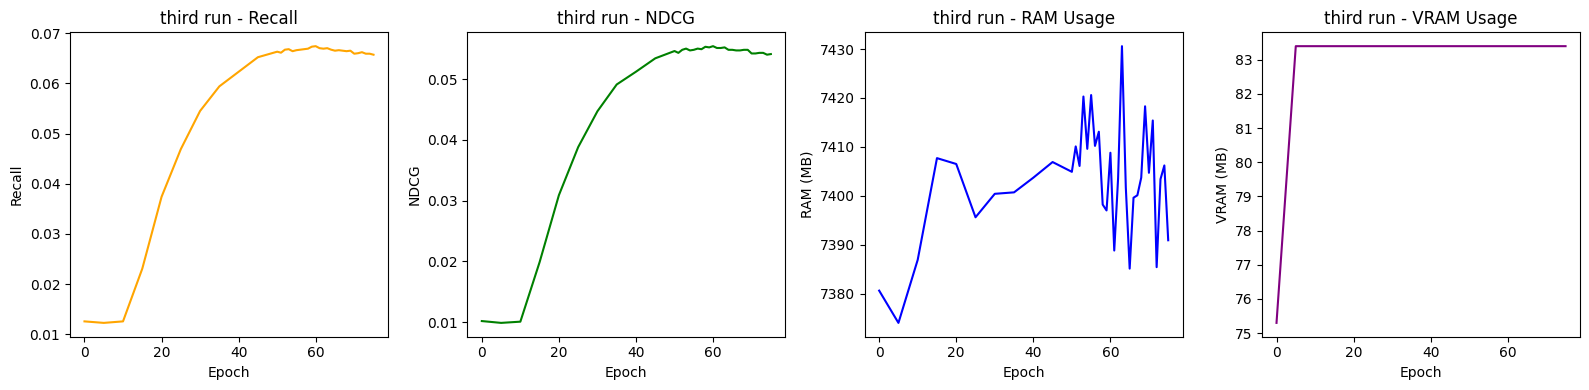

In [55]:
plot_metrics_from_log("yelp2018/third.txt")

**AmazonBook**

Average System RAM: 21106.93
Average System VRAM: 163.54


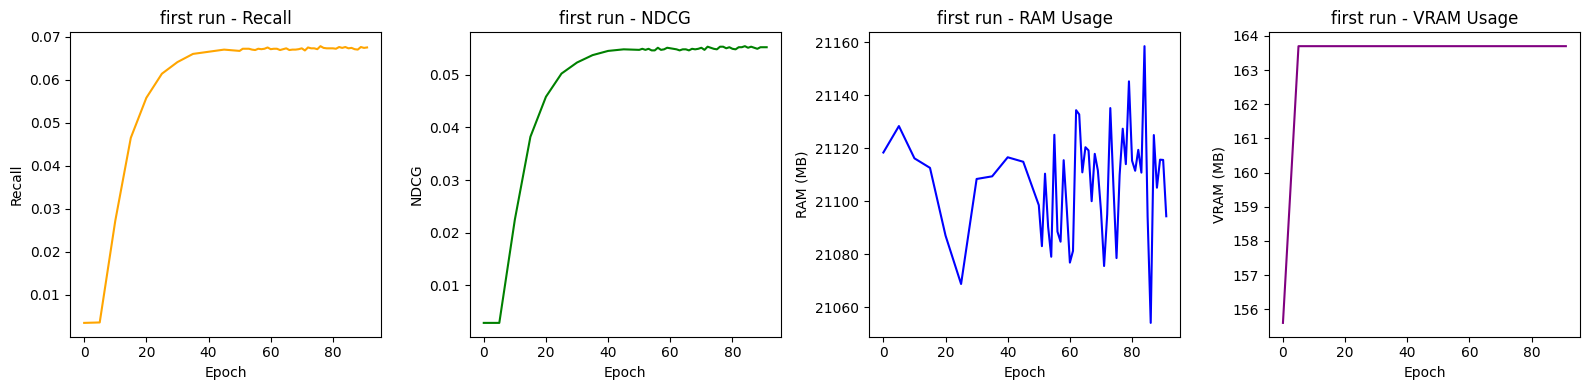

In [56]:
plot_metrics_from_log("amazonbook/first.txt")

Average System RAM: 21154.75
Average System VRAM: 163.50


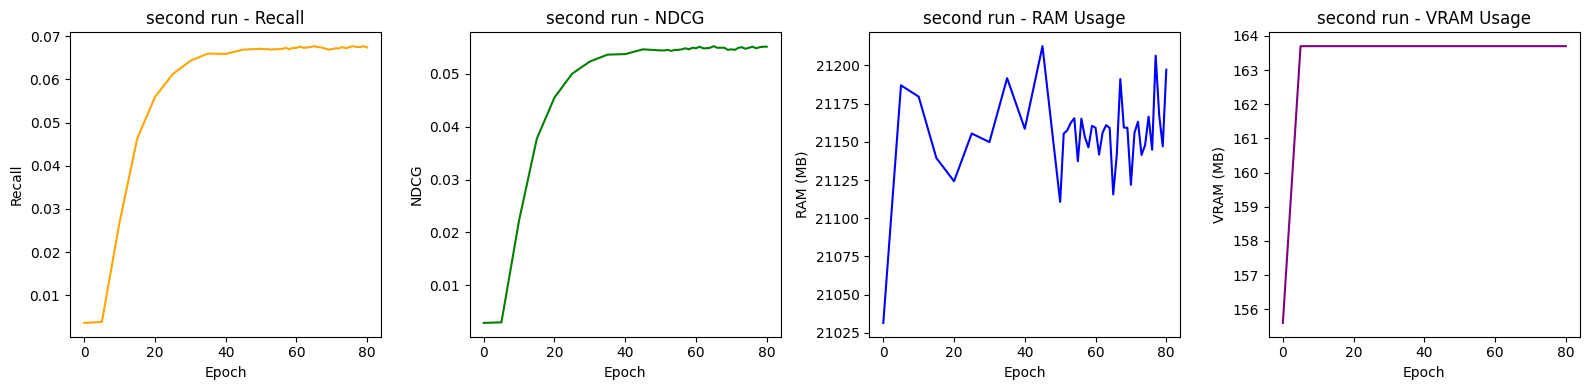

In [57]:
plot_metrics_from_log("amazonbook/second.txt")

Average System RAM: 21039.14
Average System VRAM: 163.61


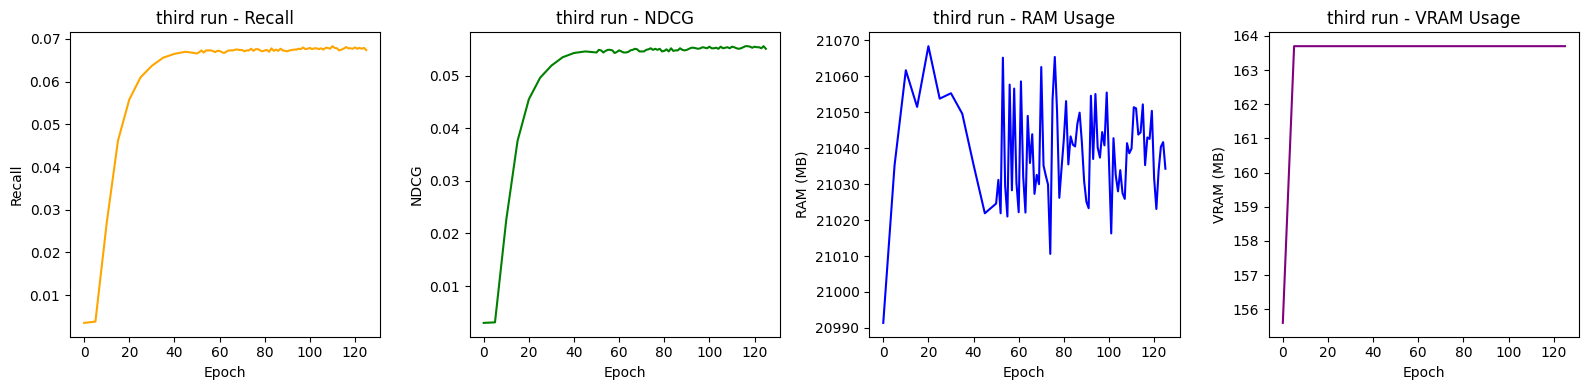

In [58]:
plot_metrics_from_log("amazonbook/third.txt")

**Gowalla**

Average System RAM: 6930.11
Average System VRAM: 84.99


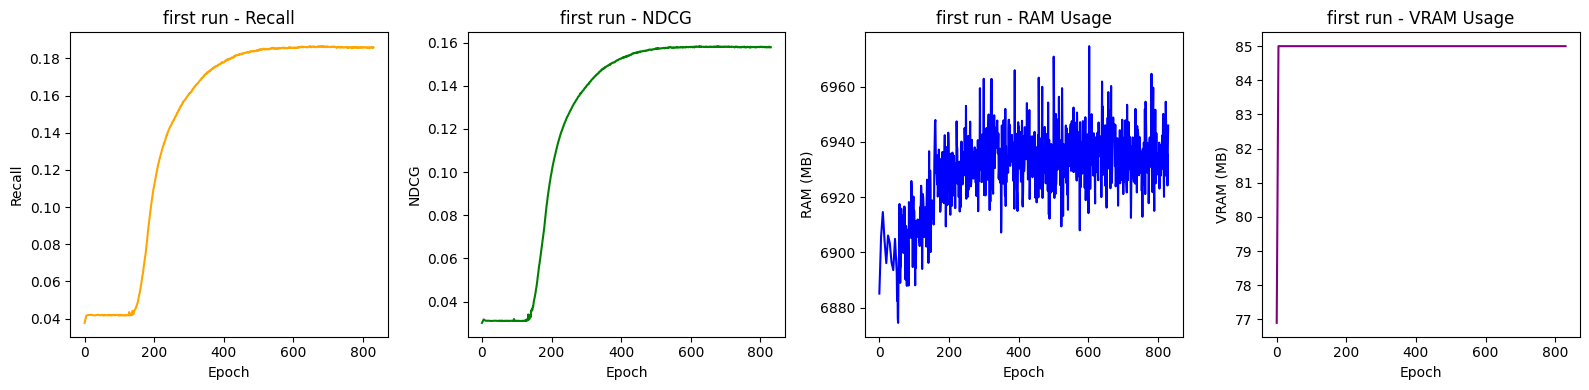

In [59]:
plot_metrics_from_log("gowalla/first.txt")

Average System RAM: 6732.12
Average System VRAM: 84.99


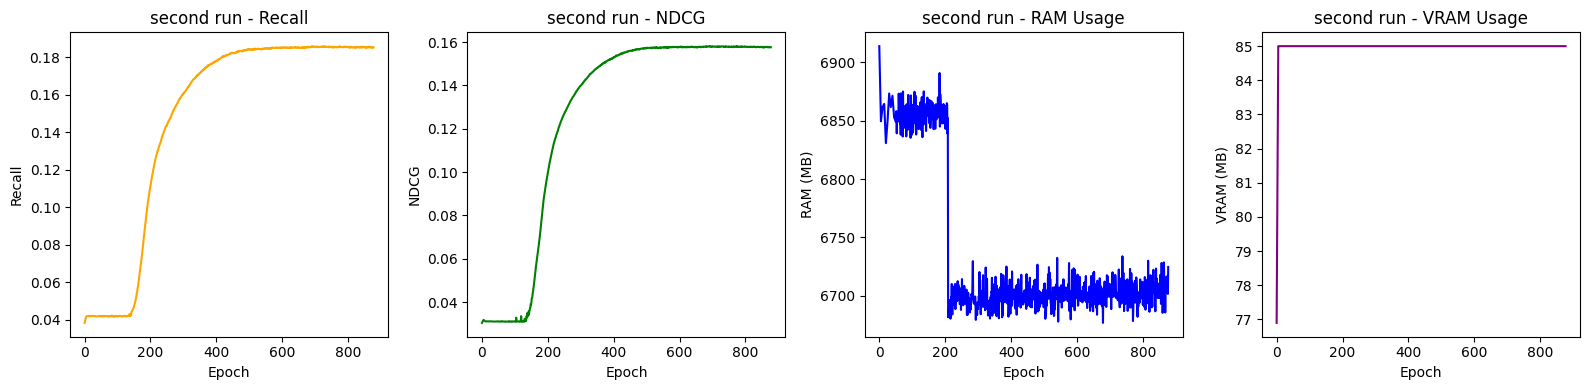

In [60]:
plot_metrics_from_log("gowalla/second.txt")

Average System RAM: 6984.48
Average System VRAM: 84.99


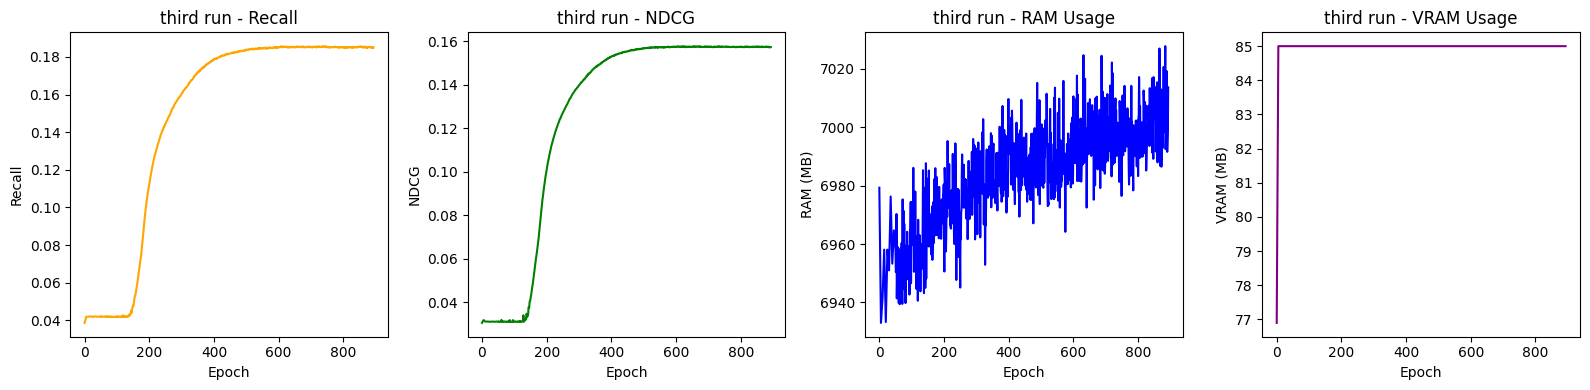

In [61]:
plot_metrics_from_log("gowalla/third.txt")

**Movielen**

Average System RAM: 2254.44
Average System VRAM: 27.92


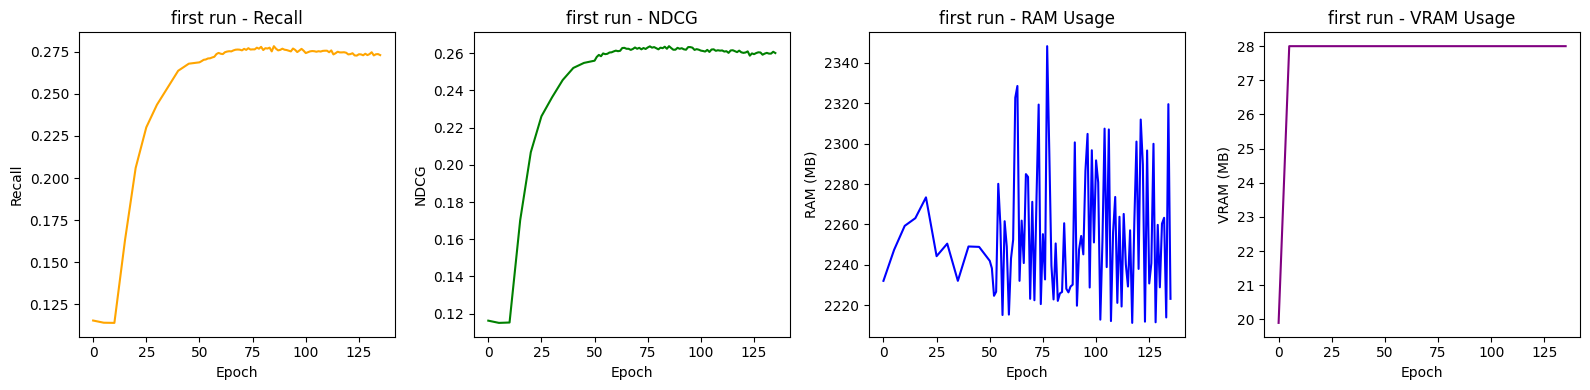

In [62]:
plot_metrics_from_log("movielen/first.txt")

Average System RAM: 2218.89
Average System VRAM: 27.92


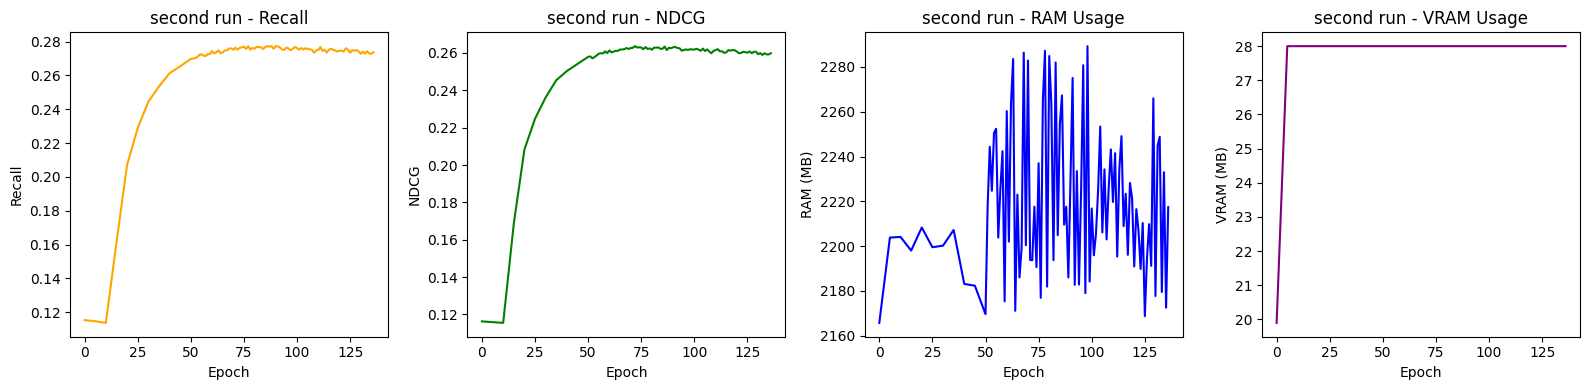

In [63]:
plot_metrics_from_log("movielen/second.txt")

Average System RAM: 2222.33
Average System VRAM: 27.92


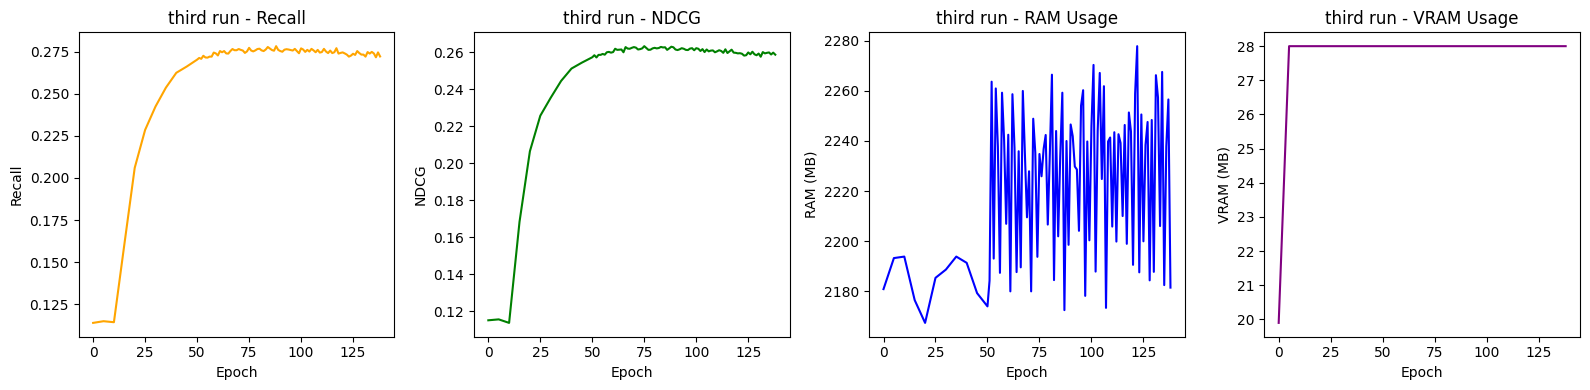

In [64]:
plot_metrics_from_log("movielen/third.txt")

**GitStar**

Average System RAM: 2584.68
Average System VRAM: 31.63


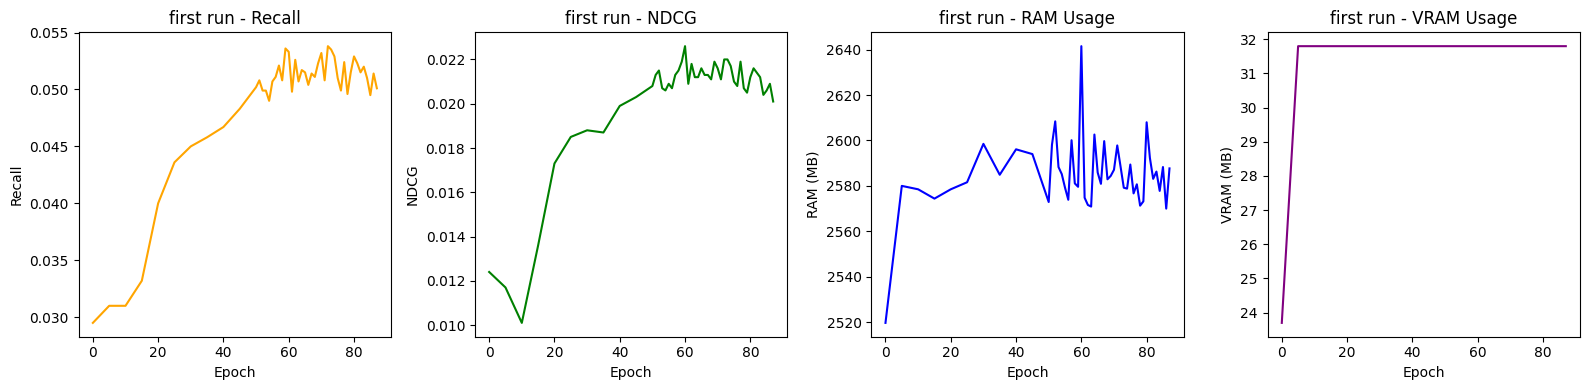

In [65]:
plot_metrics_from_log("gitstar/first.txt")

Average System RAM: 2585.74
Average System VRAM: 31.62


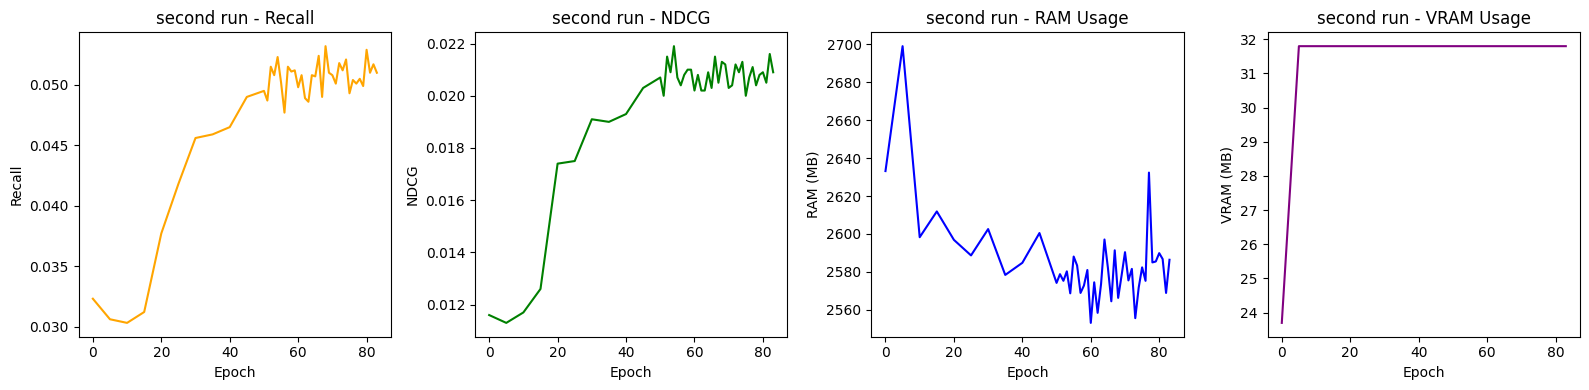

In [66]:
plot_metrics_from_log("gitstar/second.txt")

Average System RAM: 2578.84
Average System VRAM: 31.57


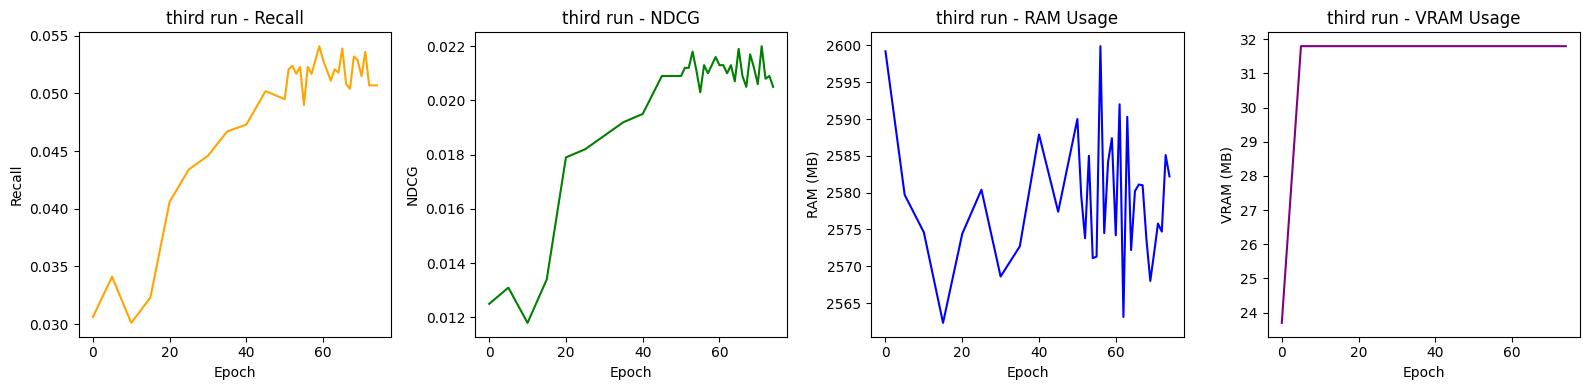

In [67]:
plot_metrics_from_log("gitstar/third.txt")